In [1]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) # don't warn us about future package conflicts

In [2]:
import pandas as pd
import xarray as xr
import numpy as np
from datetime import datetime

In [3]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import mycolors as mycmap

In [4]:
out_dir = '/pscratch/sd/p/paccini/temp/hackathon/updated_environmental_variables/'
df_prw_um = pd.read_parquet(out_dir+'UM_all/prw/')
df_rh500_um = pd.read_parquet(out_dir+'UM_all/hur/mcs_env_hur_20200201_20210331_hur_500hPa.parquet')
df_rh850_um = pd.read_parquet(out_dir+'UM_all/hur/mcs_env_hur_20200201_20210331_hur_850hPa.parquet')
df_omega500_um = pd.read_parquet(out_dir+'UM_all/omega/mcs_env_omega_20200201_20210331_omega_500hPa.parquet')
df_omega850_um = pd.read_parquet(out_dir+'UM_all/omega/mcs_env_omega_20200201_20210331_omega_850hPa.parquet')

df_prw_scream = pd.read_parquet(out_dir+'SCREAM_all/prw/')
df_rh500_scream = pd.read_parquet(out_dir+'SCREAM_all/rh500/')
df_rh850_scream = pd.read_parquet(out_dir+'SCREAM_all/rh850/')
df_omega500_scream = pd.read_parquet(out_dir+'SCREAM_all/omega500')
df_omega850_scream = pd.read_parquet(out_dir+'SCREAM_all/omega850')

df_prw_icon = pd.read_parquet(out_dir+'ICON_all/prw/')
df_rh500_icon = pd.read_parquet(out_dir+'ICON_all/hur/mcs_env_hur_20200102_20210101_hur_500hPa.parquet')
df_rh850_icon = pd.read_parquet(out_dir+'ICON_all/hur/mcs_env_hur_20200102_20210101_hur_850hPa.parquet')
df_omega500_icon = pd.read_parquet(out_dir+'ICON_all/omega/mcs_env_omega_20200102_20210101_omega_500hPa.parquet')
df_omega850_icon = pd.read_parquet(out_dir+'ICON_all/omega/mcs_env_omega_20200102_20210101_omega_850hPa.parquet')

df_prw_ifs = pd.read_parquet(out_dir+'IFS_all/tcwv/')
df_rh850_ifs = pd.read_parquet(out_dir+'IFS_all/hur/mcs_env_hur_20200101_20210301_hur_850hPa.parquet')
df_rh500_ifs = pd.read_parquet(out_dir+'IFS_all/hur/mcs_env_hur_20200101_20210301_hur_500hPa.parquet')
df_omega850_ifs = pd.read_parquet(out_dir+'IFS_all/omega/mcs_env_omega_20200101_20210301_omega_850hPa.parquet')
df_omega500_ifs = pd.read_parquet(out_dir+'IFS_all/omega/mcs_env_omega_20200101_20210301_omega_500hPa.parquet')

df_prw_nicam = pd.read_parquet(out_dir+'NICAM_all/prw/')
df_rh500_nicam = pd.read_parquet(out_dir+'NICAM_all/hur/mcs_env_hur_20200301_20210301_hur_500hPa.parquet')
df_rh850_nicam = pd.read_parquet(out_dir+'NICAM_all/hur/mcs_env_hur_20200301_20210301_hur_850hPa.parquet')
df_omega850_nicam = pd.read_parquet(out_dir+'NICAM_all/omega/mcs_env_omega_20200301_20210301_omega_850hPa.parquet')
df_omega500_nicam = pd.read_parquet(out_dir+'NICAM_all/omega/mcs_env_omega_20200301_20210301_omega_500hPa.parquet')


In [5]:
## change scream output as percents 
df_rh500_scream['mean'] = df_rh500_scream['mean']*100
df_rh850_scream['mean'] = df_rh850_scream['mean']*100
df_rh500_nicam['mean'] = df_rh500_nicam['mean']*100
df_rh850_nicam['mean'] = df_rh850_nicam['mean']*100

In [6]:
df_prw_era5 = pd.read_parquet(out_dir+'era5/TCWV/')
df_rh500_era5 = pd.read_parquet(out_dir+'era5/rh_500mb/')
df_rh850_era5 = pd.read_parquet(out_dir+'era5/rh_850mb')
df_omega500_era5 = pd.read_parquet(out_dir+'era5/w_500mb')
df_omega850_era5 = pd.read_parquet(out_dir+'era5/w_850mb')
df_q500_era5 = pd.read_parquet(out_dir+'era5/q_500mb/')
df_q850_era5 = pd.read_parquet(out_dir+'era5/q_850mb')


In [7]:
## change era5 output as g/g 
df_q500_era5['mean'] = df_q500_era5['mean']/1000
df_q850_era5['mean'] = df_q850_era5['mean']/1000

In [8]:
## Tracks of interest based on filtering criteria
main_dir = 'df_filtered_mcs_track_ids/'
# all criteria
df_trop_obs_all = pd.read_pickle(main_dir+'df_trop_obs.pkl')
df_trop_icon_all = pd.read_pickle(main_dir+'df_trop_icon.pkl')
df_trop_um_all = pd.read_pickle(main_dir+'df_trop_um.pkl')
df_trop_scream_all = pd.read_pickle(main_dir+'df_trop_scream.pkl')
df_trop_ifs_all = pd.read_pickle(main_dir+'df_trop_ifs.pkl')
df_trop_nicam_all = pd.read_pickle(main_dir+'df_trop_nicam.pkl')
# all criteria except merging ending
df_trop_obs_nm = pd.read_pickle(main_dir+'df_trop_obs_nm.pkl')
df_trop_icon_nm = pd.read_pickle(main_dir+'df_trop_icon_nm.pkl')
df_trop_um_nm = pd.read_pickle(main_dir+'df_trop_um_nm.pkl')
df_trop_scream_nm = pd.read_pickle(main_dir+'df_trop_scream_nm.pkl')
df_trop_ifs_nm = pd.read_pickle(main_dir+'df_trop_ifs_nm.pkl')
df_trop_nicam_nm = pd.read_pickle(main_dir+'df_trop_nicam_nm.pkl')
# all criteria except peak total_rain during MCS
df_trop_obs_np = pd.read_pickle(main_dir+'df_trop_obs_min_np.pkl')
df_trop_icon_np = pd.read_pickle(main_dir+'df_trop_icon_min_np.pkl')
df_trop_um_np = pd.read_pickle(main_dir+'df_trop_um_min_np.pkl')
df_trop_scream_np = pd.read_pickle(main_dir+'df_trop_scream_min_np.pkl')

### Filtering tracks

In [9]:
def get_filtered_df(df_model,df_tracks,model_track='track_id',filter_track='track_id'):
    filtered_df = df_model[df_model[model_track].isin(df_tracks[filter_track])]
    return(filtered_df)

In [10]:
def get_filtered_df_with_rain(df_model, df_tracks, model_track='track_id', filter_track='track_id',
                              var_to_merge = ['track_id','total_total_rain','mean_total_rain','duration_hours']):
    """
    Filters a model dataframe based on track IDs from a tracks dataframe
    and adds the 'total_total_rain' column.

    Args:
        df_model (pd.DataFrame): The main dataframe to be filtered.
        df_tracks (pd.DataFrame): The dataframe containing the filter keys
                                   and the 'total_total_rain' column.
        model_track (str): The name of the track ID column in df_model.
        filter_track (str): The name of the track ID column in df_tracks.

    Returns:
        pd.DataFrame: A new dataframe containing the filtered rows from
                      df_model with the 'total_total_rain' column added.
    """
    # Select only the track ID and rain columns from df_tracks for an efficient merge
    rain_data = df_tracks[var_to_merge]

    # Perform an inner merge to both filter and add the column in one step
    merged_df = pd.merge(
        df_model,
        rain_data,
        left_on=model_track,
        right_on=filter_track,
        how='inner'  # 'inner' ensures only matching track_ids are kept
    )

    # If the track ID columns had different names, the one from df_tracks is redundant
    if model_track != filter_track:
        merged_df = merged_df.drop(columns=[filter_track])

    return merged_df

In [11]:
df_prw_scream.columns

Index(['track_id', 'radius', 'data_time', 'time_offset_hours', 'mean',
       'median', 'min', 'max', 'std', 'count', 'num_valid'],
      dtype='object')

In [12]:
df_trop_scream_all.columns

Index(['track_id', 'duration_hours', 'time_to_max_area', 'initial_lat',
       'initial_lon', 'lifetime_maxmax_pf_area', 'mean_area', 'median_area',
       'total_area', 'max_total_rain', 'mean_total_rain', 'median_total_rain',
       'total_total_rain', 'mean_pf_rain', 'median_pf_rain', 'total_pf_rain',
       'mean_landfrac', 'total_landfrac', 'start_time', 'mean_eccentricity',
       'mean_aspectratio', 'mean_majoraxis', 'mean_minoraxis',
       'mean_orientation', 'median_eccentricity', 'median_aspectratio',
       'median_majoraxis', 'median_minoraxis', 'median_orientation'],
      dtype='object')

In [12]:
# df_prw_um.track_id.nunique()

In [13]:
# df_trop_um_all.track_id.nunique()

In [14]:
# df_prw_scream[df_prw_scream['track_id'].isin(df_trop_scream_all['track_id'])].track_id.nunique()

In [13]:
rr = 2; tt = 0; 
var_dfs_scream = {
    'prw': get_filtered_df_with_rain(df_prw_scream[(df_prw_scream.radius==rr)&(df_prw_scream.time_offset_hours==tt)],df_trop_scream_all),
    'rh850': get_filtered_df_with_rain(df_rh850_scream[(df_rh850_scream.radius==rr)&(df_rh850_scream.time_offset_hours==tt)],df_trop_scream_all),
    'rh500': get_filtered_df_with_rain(df_rh500_scream[(df_rh500_scream.radius==rr)&(df_rh500_scream.time_offset_hours==tt)],df_trop_scream_all),
    'omega850': get_filtered_df_with_rain(df_omega850_scream[(df_omega850_scream.radius==rr)&(df_omega850_scream.time_offset_hours==tt)],df_trop_scream_all),
    'omega500': get_filtered_df_with_rain(df_omega500_scream[(df_omega500_scream.radius==rr)&(df_omega500_scream.time_offset_hours==tt)],df_trop_scream_all),    
}

var_dfs_um = {
    'prw': get_filtered_df_with_rain(df_prw_um[(df_prw_um.radius==rr)&(df_prw_um.time_offset_hours==tt)],df_trop_um_all),
    'rh850': get_filtered_df_with_rain(df_rh850_um[(df_rh850_um.radius==rr)&(df_rh850_um.time_offset_hours==tt)],df_trop_um_all),
    'rh500': get_filtered_df_with_rain(df_rh500_um[(df_rh500_um.radius==rr)&(df_rh500_um.time_offset_hours==tt)],df_trop_um_all),
    'omega850': get_filtered_df_with_rain(df_omega850_um[(df_omega850_um.radius==rr)&(df_omega850_um.time_offset_hours==tt)],df_trop_um_all),
    'omega500': get_filtered_df_with_rain(df_omega500_um[(df_omega500_um.radius==rr)&(df_omega500_um.time_offset_hours==tt)],df_trop_um_all),
}

var_dfs_icon = {
    'prw': get_filtered_df_with_rain(df_prw_icon[(df_prw_icon.radius==rr)&(df_prw_icon.time_offset_hours==tt)],df_trop_icon_all),
    'rh850': get_filtered_df_with_rain(df_rh850_icon[(df_rh850_icon.radius==rr)&(df_rh850_icon.time_offset_hours==tt)],df_trop_icon_all),
    'rh500': get_filtered_df_with_rain(df_rh500_icon[(df_rh500_icon.radius==rr)&(df_rh500_icon.time_offset_hours==tt)],df_trop_icon_all),
    'omega850': get_filtered_df_with_rain(df_omega850_icon[(df_omega850_icon.radius==rr)&(df_omega850_icon.time_offset_hours==tt)],df_trop_icon_all),
    'omega500': get_filtered_df_with_rain(df_omega500_icon[(df_omega500_icon.radius==rr)&(df_omega500_icon.time_offset_hours==tt)],df_trop_icon_all),
}

var_dfs_ifs = {
    'prw': get_filtered_df_with_rain(df_prw_ifs[(df_prw_ifs.radius==rr)&(df_prw_ifs.time_offset_hours==tt)],df_trop_ifs_all),
    'rh850': get_filtered_df_with_rain(df_rh850_ifs[(df_rh850_ifs.radius==rr)&(df_rh850_ifs.time_offset_hours==tt)],df_trop_ifs_all),
    'rh500': get_filtered_df_with_rain(df_rh500_ifs[(df_rh500_ifs.radius==rr)&(df_rh500_ifs.time_offset_hours==tt)],df_trop_ifs_all),
    'omega850': get_filtered_df_with_rain(df_omega850_ifs[(df_omega850_ifs.radius==rr)&(df_omega850_ifs.time_offset_hours==tt)],df_trop_ifs_all),
    'omega500': get_filtered_df_with_rain(df_omega500_ifs[(df_omega500_ifs.radius==rr)&(df_omega500_ifs.time_offset_hours==tt)],df_trop_ifs_all),
}

var_dfs_nicam = {
    'prw': get_filtered_df_with_rain(df_prw_nicam[(df_prw_nicam.radius==rr)&(df_prw_nicam.time_offset_hours==tt)],df_trop_nicam_all),
    'rh850': get_filtered_df_with_rain(df_rh850_nicam[(df_rh850_nicam.radius==rr)&(df_rh850_nicam.time_offset_hours==tt)],df_trop_nicam_all),
    'rh500': get_filtered_df_with_rain(df_rh500_nicam[(df_rh500_nicam.radius==rr)&(df_rh500_nicam.time_offset_hours==tt)],df_trop_nicam_all),
    'omega850': get_filtered_df_with_rain(df_omega850_nicam[(df_omega850_nicam.radius==rr)&(df_omega850_nicam.time_offset_hours==tt)],df_trop_nicam_all),
    'omega500': get_filtered_df_with_rain(df_omega500_nicam[(df_omega500_nicam.radius==rr)&(df_omega500_nicam.time_offset_hours==tt)],df_trop_nicam_all),
}


var_dfs_era5 = {
    'prw': get_filtered_df_with_rain(df_prw_era5[(df_prw_era5.radius==rr)&(df_prw_era5.time_offset_hours==tt)],df_trop_obs_all),
    'rh850': get_filtered_df_with_rain(df_rh850_era5[(df_rh850_era5.radius==rr)&(df_rh850_era5.time_offset_hours==tt)],df_trop_obs_all),
    'rh500': get_filtered_df_with_rain(df_rh500_era5[(df_rh500_era5.radius==rr)&(df_rh500_era5.time_offset_hours==tt)],df_trop_obs_all),
    'omega850': get_filtered_df_with_rain(df_omega850_era5[(df_omega850_era5.radius==rr)&(df_omega850_era5.time_offset_hours==tt)],df_trop_obs_all),
    'omega500': get_filtered_df_with_rain(df_omega500_era5[(df_omega500_era5.radius==rr)&(df_omega500_era5.time_offset_hours==tt)],df_trop_obs_all),}

In [14]:
rr = 2; tt = 0
var_dfs_scream_nm = {
    'prw': get_filtered_df_with_rain(df_prw_scream[(df_prw_scream.radius==rr)&(df_prw_scream.time_offset_hours==tt)],df_trop_scream_nm),
    'rh850': get_filtered_df_with_rain(df_rh850_scream[(df_rh850_scream.radius==rr)&(df_rh850_scream.time_offset_hours==tt)],df_trop_scream_nm),
    'rh500': get_filtered_df_with_rain(df_rh500_scream[(df_rh500_scream.radius==rr)&(df_rh500_scream.time_offset_hours==tt)],df_trop_scream_nm),
    'omega850': get_filtered_df_with_rain(df_omega850_scream[(df_omega850_scream.radius==rr)&(df_omega850_scream.time_offset_hours==tt)],df_trop_scream_nm),
    'omega500': get_filtered_df_with_rain(df_omega500_scream[(df_omega500_scream.radius==rr)&(df_omega500_scream.time_offset_hours==tt)],df_trop_scream_nm),    
}

var_dfs_um_nm = {
    'prw': get_filtered_df_with_rain(df_prw_um[(df_prw_um.radius==rr)&(df_prw_um.time_offset_hours==tt)],df_trop_um_nm),
    'rh850': get_filtered_df_with_rain(df_rh850_um[(df_rh850_um.radius==rr)&(df_rh850_um.time_offset_hours==tt)],df_trop_um_nm),
    'rh500': get_filtered_df_with_rain(df_rh500_um[(df_rh500_um.radius==rr)&(df_rh500_um.time_offset_hours==tt)],df_trop_um_nm),
    'omega850': get_filtered_df_with_rain(df_omega850_um[(df_omega850_um.radius==rr)&(df_omega850_um.time_offset_hours==tt)],df_trop_um_nm),
    'omega500': get_filtered_df_with_rain(df_omega500_um[(df_omega500_um.radius==rr)&(df_omega500_um.time_offset_hours==tt)],df_trop_um_nm),
}

var_dfs_icon_nm = {
    'prw': get_filtered_df_with_rain(df_prw_icon[(df_prw_icon.radius==rr)&(df_prw_icon.time_offset_hours==tt)],df_trop_icon_nm),
    'rh850': get_filtered_df_with_rain(df_rh850_icon[(df_rh850_icon.radius==rr)&(df_rh850_icon.time_offset_hours==tt)],df_trop_icon_nm),
    'rh500': get_filtered_df_with_rain(df_rh500_icon[(df_rh500_icon.radius==rr)&(df_rh500_icon.time_offset_hours==tt)],df_trop_icon_nm),
    'omega850': get_filtered_df_with_rain(df_omega850_icon[(df_omega850_icon.radius==rr)&(df_omega850_icon.time_offset_hours==tt)],df_trop_icon_nm),
    'omega500': get_filtered_df_with_rain(df_omega500_icon[(df_omega500_icon.radius==rr)&(df_omega500_icon.time_offset_hours==tt)],df_trop_icon_nm),
}

var_dfs_ifs_nm = {
    'prw': get_filtered_df_with_rain(df_prw_ifs[(df_prw_ifs.radius==rr)&(df_prw_ifs.time_offset_hours==tt)],df_trop_ifs_nm),
    'rh850': get_filtered_df_with_rain(df_rh850_ifs[(df_rh850_ifs.radius==rr)&(df_rh850_ifs.time_offset_hours==tt)],df_trop_ifs_nm),
    'rh500': get_filtered_df_with_rain(df_rh500_ifs[(df_rh500_ifs.radius==rr)&(df_rh500_ifs.time_offset_hours==tt)],df_trop_ifs_nm),
    'omega850': get_filtered_df_with_rain(df_omega850_ifs[(df_omega850_ifs.radius==rr)&(df_omega850_ifs.time_offset_hours==tt)],df_trop_ifs_nm),
    'omega500': get_filtered_df_with_rain(df_omega500_ifs[(df_omega500_ifs.radius==rr)&(df_omega500_ifs.time_offset_hours==tt)],df_trop_ifs_nm),
}

var_dfs_nicam_nm = {
    'prw': get_filtered_df_with_rain(df_prw_nicam[(df_prw_nicam.radius==rr)&(df_prw_nicam.time_offset_hours==tt)],df_trop_nicam_nm),
    'rh850': get_filtered_df_with_rain(df_rh850_nicam[(df_rh850_nicam.radius==rr)&(df_rh850_nicam.time_offset_hours==tt)],df_trop_nicam_nm),
    'rh500': get_filtered_df_with_rain(df_rh500_nicam[(df_rh500_nicam.radius==rr)&(df_rh500_nicam.time_offset_hours==tt)],df_trop_nicam_nm),
    'omega850': get_filtered_df_with_rain(df_omega850_nicam[(df_omega850_nicam.radius==rr)&(df_omega850_nicam.time_offset_hours==tt)],df_trop_nicam_nm),
    'omega500': get_filtered_df_with_rain(df_omega500_nicam[(df_omega500_nicam.radius==rr)&(df_omega500_nicam.time_offset_hours==tt)],df_trop_nicam_nm),
}

var_dfs_era5_nm = {
    'prw': get_filtered_df_with_rain(df_prw_era5[(df_prw_era5.radius==rr)&(df_prw_era5.time_offset_hours==tt)],df_trop_obs_nm),
    'rh850': get_filtered_df_with_rain(df_rh850_era5[(df_rh850_era5.radius==rr)&(df_rh850_era5.time_offset_hours==tt)],df_trop_obs_nm),
    'rh500': get_filtered_df_with_rain(df_rh500_era5[(df_rh500_era5.radius==rr)&(df_rh500_era5.time_offset_hours==tt)],df_trop_obs_nm),
    'omega850': get_filtered_df_with_rain(df_omega850_era5[(df_omega850_era5.radius==rr)&(df_omega850_era5.time_offset_hours==tt)],df_trop_obs_nm),
    'omega500': get_filtered_df_with_rain(df_omega500_era5[(df_omega500_era5.radius==rr)&(df_omega500_era5.time_offset_hours==tt)],df_trop_obs_nm),}

In [14]:
var_dfs_scream = {
    'prw': get_filtered_df_with_rain(df_prw_scream[(df_prw_scream.radius==rr)&(df_prw_scream.time_offset_hours==tt)],df_trop_scream_np),
    'rh850': get_filtered_df_with_rain(df_rh850_scream[(df_rh850_scream.radius==rr)&(df_rh850_scream.time_offset_hours==tt)],df_trop_scream_np),
    'rh500': get_filtered_df_with_rain(df_rh500_scream[(df_rh500_scream.radius==rr)&(df_rh500_scream.time_offset_hours==tt)],df_trop_scream_np),
    'omega850': get_filtered_df_with_rain(df_omega850_scream[(df_omega850_scream.radius==rr)&(df_omega850_scream.time_offset_hours==tt)],df_trop_scream_np),
    'omega500': get_filtered_df_with_rain(df_omega500_scream[(df_omega500_scream.radius==rr)&(df_omega500_scream.time_offset_hours==tt)],df_trop_scream_np),    
}

var_dfs_um = {
    'prw': get_filtered_df_with_rain(df_prw_um[(df_prw_um.radius==rr)&(df_prw_um.time_offset_hours==tt)],df_trop_um_np),
    'rh850': get_filtered_df_with_rain(df_rh850_um[(df_rh850_um.radius==rr)&(df_rh850_um.time_offset_hours==tt)],df_trop_um_np),
    'rh500': get_filtered_df_with_rain(df_rh500_um[(df_rh500_um.radius==rr)&(df_rh500_um.time_offset_hours==tt)],df_trop_um_np),
    'omega850': get_filtered_df_with_rain(df_omega850_um[(df_omega850_um.radius==rr)&(df_omega850_um.time_offset_hours==tt)],df_trop_um_np),
    'omega500': get_filtered_df_with_rain(df_omega500_um[(df_omega500_um.radius==rr)&(df_omega500_um.time_offset_hours==tt)],df_trop_um_np),
}

var_dfs_icon = {
    'prw': get_filtered_df_with_rain(df_prw_icon[(df_prw_icon.radius==rr)&(df_prw_icon.time_offset_hours==tt)],df_trop_icon_all),
    'rh850': get_filtered_df_with_rain(df_rh850_icon[(df_rh850_icon.radius==rr)&(df_rh850_icon.time_offset_hours==tt)],df_trop_icon_np),
    'rh500': get_filtered_df_with_rain(df_rh500_icon[(df_rh500_icon.radius==rr)&(df_rh500_icon.time_offset_hours==tt)],df_trop_icon_np),
    'omega850': get_filtered_df_with_rain(df_omega850_icon[(df_omega850_icon.radius==rr)&(df_omega850_icon.time_offset_hours==tt)],df_trop_icon_np),
    'omega500': get_filtered_df_with_rain(df_omega500_icon[(df_omega500_icon.radius==rr)&(df_omega500_icon.time_offset_hours==tt)],df_trop_icon_np),
}

var_dfs_era5 = {
    'prw': get_filtered_df_with_rain(df_prw_era5[(df_prw_era5.radius==rr)&(df_prw_era5.time_offset_hours==tt)],df_trop_obs_np),
    'rh850': get_filtered_df_with_rain(df_rh850_era5[(df_rh850_era5.radius==rr)&(df_rh850_era5.time_offset_hours==tt)],df_trop_obs_np),
    'rh500': get_filtered_df_with_rain(df_rh500_era5[(df_rh500_era5.radius==rr)&(df_rh500_era5.time_offset_hours==tt)],df_trop_obs_np),
    'omega850': get_filtered_df_with_rain(df_omega850_era5[(df_omega850_era5.radius==rr)&(df_omega850_era5.time_offset_hours==tt)],df_trop_obs_np),
    'omega500': get_filtered_df_with_rain(df_omega500_era5[(df_omega500_era5.radius==rr)&(df_omega500_era5.time_offset_hours==tt)],df_trop_obs_np),}

In [18]:
# del(is_missing_mask, missing_tracks_df)
# is_missing_mask = ~df_trop_icon_all['track_id'].isin(read_lf['track_id'])

# # 2. Use that mask to filter df_tracks directly
# missing_tracks_df = df_trop_icon_all[is_missing_mask]

In [15]:
def get_composite_data(df_1, df_2, var1= 'mean', ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=10, key_cols= ['track_id'],
                       value_feature = 'total_total_rain'):
    df_1 = df_1.rename(columns={var1: ren_var1})
    df_2 = df_2.rename(columns={var2: ren_var2})
    df_merged = df_1.merge(df_2[key_cols + [ren_var2]], on=key_cols, how='left')    

    feature_1 = ren_var1; 
    bin_labels_1 = [f'Bin {i+1}' for i in range(varbins)]
    df_merged[f'{feature_1}_bin'] = pd.qcut(df_merged[feature_1], q=varbins, labels=bin_labels_1, duplicates='drop')
    bins_for_labels_1 = pd.qcut(df_merged[feature_1], q=varbins, duplicates='drop').cat.categories
    
    feature_2 = ren_var2;
    bin_labels_2 = [f'Bin {i+1}' for i in range(varbins)]
    df_merged[f'{feature_2}_bin'] = pd.qcut(df_merged[feature_2], q=varbins, labels=bin_labels_2, duplicates='drop')
    bins_for_labels_2 = pd.qcut(df_merged[feature_2], q=varbins, duplicates='drop').cat.categories

    
    composite_data = df_merged.groupby([f'{feature_1}_bin',f'{feature_2}_bin'])[value_feature].mean().unstack()
    return(composite_data,value_feature, feature_1,feature_2)

In [15]:
def create_composite_grid(df_1, df_2, var1='mean', ren_var1='mean_rh850',
                          var2='mean', ren_var2='mean_omega850', varbins=5,
                          key_cols=['track_id'],
                          value_feature='total_total_rain'):
    """
    Merges two dataframes and creates 2D composite grids for both the mean and
    the count of a value feature, based on bins of two other features.
    """
    # Prepare dataframes by renaming and merging
    df_1 = df_1.rename(columns={var1: ren_var1})
    df_2 = df_2.rename(columns={var2: ren_var2})
    # Ensure value_feature is in the first dataframe for the merge
    merge_cols_df1 = key_cols + [ren_var1, value_feature]
    df_merged = df_1[merge_cols_df1].merge(df_2[key_cols + [ren_var2]], on=key_cols, how='inner')
    df_merged.dropna(subset=[ren_var1, ren_var2, value_feature], inplace=True)

    # Bin the two primary features (e.g., humidity and vertical velocity)
    df_merged[f'{ren_var1}_bin'] = pd.qcut(df_merged[ren_var1], q=varbins, labels=False, duplicates='drop')
    df_merged[f'{ren_var2}_bin'] = pd.qcut(df_merged[ren_var2], q=varbins, labels=False, duplicates='drop')

    # Group by the new bins and calculate both mean and count
    composite_stats = df_merged.groupby([f'{ren_var1}_bin', f'{ren_var2}_bin'])[value_feature].agg(['mean', 'count'])

    # Unstack to create the 2D grids
    composite_mean = composite_stats['mean'].unstack()
    composite_count = composite_stats['count'].unstack()

    # Get bin edges for labeling the plot axes later
    # We'll use the original qcut results for this
    mean_bin_edges_1 = pd.qcut(df_merged[ren_var1], q=varbins, duplicates='drop').cat.categories
    mean_bin_edges_2 = pd.qcut(df_merged[ren_var2], q=varbins, duplicates='drop').cat.categories
    
    # Store metadata for plotting
    plot_info = {
        'value_feature': value_feature,
        'feature_1': ren_var1,
        'feature_2': ren_var2,
        'bin_edges_1': mean_bin_edges_1,
        'bin_edges_2': mean_bin_edges_2
    }
    
    return composite_mean, composite_count, plot_info

In [16]:
def remove_precipitation_extremes(df_merged, value_feature='total_total_rain', p_low=0.1, p_high=0.9):
    """
    Remove precipitation extremes before binning to avoid skewing bin means.
    
    Parameters:
    -----------
    df_merged : pd.DataFrame
        Merged dataframe with environmental variables and precipitation feature
    value_feature : str
        Column name of the precipitation feature to filter
    p_low : float
        Lower percentile threshold (default: 0.1 for 10th percentile)
    p_high : float
        Upper percentile threshold (default: 0.9 for 90th percentile)
        
    Returns:
    --------
    pd.DataFrame
        Filtered dataframe without precipitation extremes
    """
    q_low = df_merged[value_feature].quantile(p_low)
    q_high = df_merged[value_feature].quantile(p_high)
    
    df_filtered = df_merged[
        (df_merged[value_feature] >= q_low) & 
        (df_merged[value_feature] <= q_high)
    ].copy()
    
    n_removed = len(df_merged) - len(df_filtered)
    print(f"Removed {n_removed} samples ({n_removed/len(df_merged)*100:.1f}%) outside [{q_low:.2f}, {q_high:.2f}] range")
    
    return df_filtered

In [18]:
test = var_dfs_ifs['rh500'] #var_dfs_scream['omega850'] #.duration_hours.quantile(0.9)

In [19]:
test[test.duration_hours<=test.duration_hours.quantile(0.9)].total_total_rain.describe()

count       764.000000
mean      30711.537109
std       37429.332031
min        1774.946777
25%       10757.533691
50%       19782.407227
75%       37617.852539
max      548844.312500
Name: total_total_rain, dtype: float64

In [17]:
def create_composite_grid_filtered(df_1, df_2, var1='mean', ren_var1='mean_rh850',
                          var2='mean', ren_var2='mean_omega850', varbins=5, 
                          key_cols=['track_id','duration_hours'],
                          value_feature='total_total_rain', 
                          filter_extremes=True, p_low=0.05, p_high=0.95,
                          min_count=10):
    """
    Enhanced version of create_composite_grid that:
    1. Removes precipitation extremes before binning
    2. Masks bins with fewer than min_count samples
    
    Parameters:
    -----------
    filter_extremes : bool
        If True, remove precipitation extremes before binning
    p_low, p_high : float
        Percentile thresholds for filtering extremes
    min_count : int
        Minimum number of samples required per bin (bins with fewer will be masked as NaN)
    """
    # Prepare dataframes by renaming and merging
    df_1 = df_1.rename(columns={var1: ren_var1})
    df_2 = df_2.rename(columns={var2: ren_var2})
    merge_cols_df1 = key_cols + [ren_var1, value_feature]
    df_merged = df_1[merge_cols_df1].merge(df_2[key_cols + [ren_var2]], on=key_cols, how='inner')
    df_merged.dropna(subset=[ren_var1, ren_var2, value_feature], inplace=True)
    
    # Remove precipitation extremes
    if filter_extremes:
        df_merged = remove_precipitation_extremes(df_merged[df_merged.duration_hours<=df_merged.duration_hours.quantile(0.9)], value_feature, p_low, p_high)

    # Bin the two primary features
    df_merged[f'{ren_var1}_bin'] = pd.qcut(df_merged[ren_var1], q=varbins, labels=False, duplicates='drop')
    df_merged[f'{ren_var2}_bin'] = pd.qcut(df_merged[ren_var2], q=varbins, labels=False, duplicates='drop')

    # Group by bins and calculate mean and count
    composite_stats = df_merged.groupby([f'{ren_var1}_bin', f'{ren_var2}_bin'])[value_feature].agg(['mean', 'count'])

    # Unstack to create 2D grids
    composite_mean = composite_stats['mean'].unstack()
    composite_count = composite_stats['count'].unstack()
    
    # Mask bins with fewer than min_count samples
    composite_mean_masked = composite_mean.where(composite_count >= min_count)

    # Get bin edges for labeling
    mean_bin_edges_1 = pd.qcut(df_merged[ren_var1], q=varbins, duplicates='drop').cat.categories
    mean_bin_edges_2 = pd.qcut(df_merged[ren_var2], q=varbins, duplicates='drop').cat.categories
    
    plot_info = {
        'value_feature': value_feature,
        'feature_1': ren_var1,
        'feature_2': ren_var2,
        'bin_edges_1': mean_bin_edges_1,
        'bin_edges_2': mean_bin_edges_2
    }
    
    return composite_mean_masked, composite_count, plot_info

In [18]:
def plot_all_models_composite(model_data_dict, var1='rh850', var2='omega850',
                             var1_col='mean', var2_col='mean',
                             ren_var1='mean_rh850', ren_var2='mean_omega850',
                             varbins=5, value_feature='mean_total_rain',
                             filter_extremes=True, p_low=0.1, p_high=0.9,
                             min_count=10, normalize=True, norm_method='quantile',
                             cmap='viridis', figsize=(15, 10), suptitle=""):
    """
    Plot composite analysis for all models in a single figure.
    
    Parameters:
    -----------
    model_data_dict : dict
        Dictionary with model names as keys and their data dictionaries as values.
        Each data dictionary should contain the environmental variable dataframes.
        Example: {'SCREAM': var_dfs_scream, 'UM': var_dfs_um, ...}
    normalize : bool
        Whether to normalize the data
    norm_method : str
        'quantile' for quantile-based (0.1, 0.9) or 'minmax' for min/max normalization
    """
    from matplotlib.colors import BoundaryNorm
    from matplotlib.ticker import MaxNLocator
    
    n_models = len(model_data_dict)
    ncols = 3
    nrows = (n_models + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,sharex=True, sharey=True)
    if n_models == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Store all composites
    composites = {}
    
    # First pass: create all composites
    for model_name, var_dfs in model_data_dict.items():
        composite_mean, composite_count, plot_info = create_composite_grid_filtered(
            var_dfs[var1], var_dfs[var2],
            var1=var1_col, ren_var1=ren_var1,
            var2=var2_col, ren_var2=ren_var2,
            varbins=varbins, value_feature=value_feature,
            filter_extremes=filter_extremes, p_low=p_low, p_high=p_high,
            min_count=min_count
        )
        composites[model_name] = (composite_mean, composite_count, plot_info)
    
    # Set colorbar range (0-1 for normalized, or global min/max for absolute)
    if normalize:
        vmin, vmax = 0, 1
    else:
        # For absolute values, use global min/max across all models
        all_data = []
        for composite_mean, _, _ in composites.values():
            all_data.append(composite_mean.values.flatten())
        all_data_flat = np.concatenate(all_data)
        all_data_flat = all_data_flat[~np.isnan(all_data_flat)]
        vmin = np.nanmin(all_data_flat)
        vmax = np.nanmax(all_data_flat)
    
    # Second pass: plot all composites
    for idx, (model_name, (composite_mean, composite_count, plot_info)) in enumerate(composites.items()):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        data = composite_mean.values.copy()
        
        # Normalize each model independently based on its own data
        if normalize:
            data_flat = data[~np.isnan(data)]
            if len(data_flat) > 0:
                if norm_method == 'quantile':
                    vmin_model = np.quantile(data_flat, p_low)
                    vmax_model = np.quantile(data_flat, p_high)
                else:  # minmax
                    vmin_model = np.nanmin(data_flat)
                    vmax_model = np.nanmax(data_flat)
                
                # Normalize to 0-1 range based on model's own data
                if vmax_model > vmin_model:
                    data = (data - vmin_model) / (vmax_model - vmin_model)
                    data = np.clip(data, 0, 1)
                else:
                    data = np.full_like(data, 0.5)  # Handle edge case
        
        # Create colormap and norm
        levels = MaxNLocator(nbins=20).tick_values(vmin, vmax)
        norm = BoundaryNorm(levels, ncolors=plt.get_cmap(cmap).N, clip=True)
        
        # Plot (don't pass vmin/vmax when using BoundaryNorm)
        mesh = ax.pcolormesh(data, cmap=cmap, norm=norm)
        
        # Add hatching or stippling for masked (low count) bins
        for i in range(composite_mean.shape[0]):
            for j in range(composite_mean.shape[1]):
                if np.isnan(composite_mean.values[i, j]):
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, 
                                              fill=False, edgecolor='gray', 
                                              hatch='///', linewidth=0))
        
        # Labels
        ax.set_xticks(np.arange(composite_mean.shape[1]) + 0.5)
        ax.set_xticklabels(range(composite_mean.shape[1]), fontsize=8)
        ax.set_xlabel(f"{plot_info['feature_2']}", fontsize=9)
        
        ax.set_yticks(np.arange(composite_mean.shape[0]) + 0.5)
        ax.set_yticklabels(range(composite_mean.shape[0]), fontsize=8)
        ax.set_ylabel(f"{plot_info['feature_1']}", fontsize=9)
        
        ax.set_title(f"{model_name} (N={int(composite_count.sum().sum())})", fontsize=10, fontweight='bold')
    
    # Hide unused axes
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)
    
    # Add colorbar
    cbar_label = f"{'Normalized ' if normalize else ''}{value_feature}"
    if normalize and norm_method == 'quantile':
        cbar_label += f" (P{int(p_low*100)}-P{int(p_high*100)})"
    
    fig.colorbar(mesh, ax=axes[:n_models], label=cbar_label, 
                 shrink=0.8, pad=0.02, aspect=30)
    
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=0.98)
    
    # plt.tight_layout()
    return fig, axes, composites

In [19]:
def plot_all_models_counts(composites_dict, cmap='plasma', figsize=(15, 10), 
                          suptitle="Sample Counts per Bin"):
    """
    Plot sample counts for all models in a single figure.
    
    Parameters:
    -----------
    composites_dict : dict
        Dictionary returned by plot_all_models_composite containing composites for each model
    """
    n_models = len(composites_dict)
    ncols = 3
    nrows = (n_models + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,sharex=True, sharey=True)
    if n_models == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, (model_name, (composite_mean, composite_count, plot_info)) in enumerate(composites_dict.items()):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        data_count = composite_count.fillna(0).values
        
        # Use log scale for better visualization
        mesh = ax.pcolormesh(data_count, cmap=cmap, 
                           norm=plt.cm.colors.LogNorm(vmin=max(1, data_count[data_count > 0].min()), 
                                                       vmax=data_count.max()))
        
        # Add count text
        for i in range(composite_count.shape[0]):
            for j in range(composite_count.shape[1]):
                count_val = int(data_count[i, j])
                if count_val > 0:
                    text_color = 'white' if count_val > data_count.max() / 3 else 'black'
                    ax.text(j + 0.5, i + 0.5, f'{count_val}',
                           ha='center', va='center', color=text_color, fontsize=7)
        
        # Labels
        ax.set_xticks(np.arange(composite_count.shape[1]) + 0.5)
        ax.set_xticklabels(range(composite_count.shape[1]), fontsize=8)
        ax.set_xlabel(f"{plot_info['feature_2']}", fontsize=9)
        
        ax.set_yticks(np.arange(composite_count.shape[0]) + 0.5)
        ax.set_yticklabels(range(composite_count.shape[0]), fontsize=8)
        ax.set_ylabel(f"{plot_info['feature_1']}", fontsize=9)
        
        total_samples = int(composite_count.sum().sum())
        ax.set_title(f"{model_name} (Total N={total_samples})", fontsize=10, fontweight='bold')
        
        fig.colorbar(mesh, ax=ax, label="Sample Count (Log Scale)", shrink=0.8)
    
    # Hide unused axes
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)
    
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    return fig, axes

## Multi-Model Composite Analysis

The new functions provide enhanced capabilities:
1. **`remove_precipitation_extremes()`**: Filters out p10-p90 extremes before binning
2. **`create_composite_grid_filtered()`**: Creates composite with extreme filtering and minimum count masking
3. **`plot_all_models_composite()`**: Plots all models in one figure with consistent normalization
4. **`plot_all_models_counts()`**: Plots sample counts for all models

Key features:
- **Extreme filtering**: Removes precipitation extremes (default: p10, p90) before computing bin means
- **Minimum count threshold**: Bins with < 10 samples are masked (shown with red hatching)
- **Normalization options**: 
  - `norm_method='quantile'`: Normalizes using p10-p90 range (default)
  - `norm_method='minmax'`: Normalizes using min-max range
- **Consistent colorbar**: All models use the same scale for easy comparison

Removed 176 samples (10.0%) outside [4432.30, 47084.79] range
Removed 236 samples (10.0%) outside [5112.86, 70787.28] range
Removed 74 samples (10.2%) outside [3323.40, 54579.57] range
Removed 78 samples (10.2%) outside [4643.91, 89065.25] range
Removed 208 samples (10.0%) outside [4563.53, 72873.03] range
Removed 256 samples (10.0%) outside [7218.32, 118650.42] range


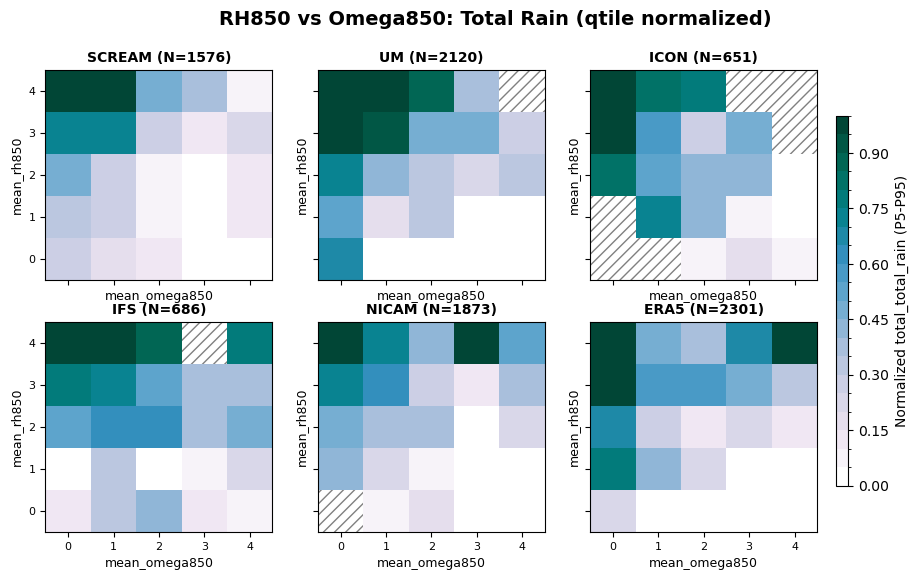

In [26]:
# Example 1: Plot all models with quantile normalization and extreme filtering
model_data = {'SCREAM': var_dfs_scream,   'UM': var_dfs_um, 'ICON': var_dfs_icon,   'IFS': var_dfs_ifs,
    'NICAM': var_dfs_nicam,    'ERA5': var_dfs_era5}

fig, axes, composites = plot_all_models_composite(
    model_data,var1='rh850', var2='omega850',
    varbins=5,value_feature='total_total_rain',
    filter_extremes=True,  # Remove p10-p90 extremes
    p_low=0.05, p_high=0.95,  # Extremes threshold
    min_count=15,  # Mask bins with < 10 samples
    normalize=True,  # Normalize data
    norm_method='quantile',  # Use quantile normalization (p10-p90)
    cmap=mycmap.whiteTOblueTOgreen,
    figsize=(12, 6),
    suptitle="RH850 vs Omega850: Total Rain (qtile normalized)"
)

Removed 298 samples (10.0%) outside [4652.27, 52304.25] range
Removed 414 samples (10.0%) outside [5045.64, 70184.32] range
Removed 166 samples (10.1%) outside [3212.27, 64702.58] range
Removed 158 samples (10.1%) outside [5066.90, 104401.87] range
Removed 380 samples (10.0%) outside [5078.71, 76187.15] range
Removed 384 samples (10.0%) outside [7204.49, 123990.54] range


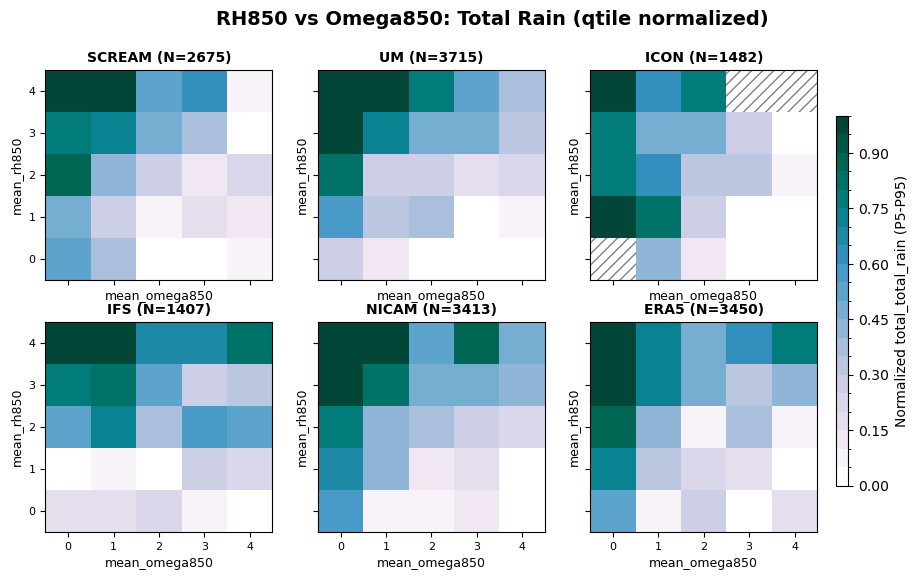

In [27]:
model_data_nm = {'SCREAM': var_dfs_scream_nm,   'UM': var_dfs_um_nm, 'ICON': var_dfs_icon_nm,   'IFS': var_dfs_ifs_nm,
    'NICAM': var_dfs_nicam_nm,    'ERA5': var_dfs_era5_nm}

fig, axes, composites = plot_all_models_composite(
    model_data_nm,var1='rh850', var2='omega850',
    varbins=5,value_feature='total_total_rain',
    filter_extremes=True,  # Remove p10-p90 extremes
    p_low=0.05, p_high=0.95,  # Extremes threshold
    min_count=15,  # Mask bins with < 10 samples
    normalize=True,  # Normalize data
    norm_method='quantile',  # Use quantile normalization (p10-p90)
    cmap=mycmap.whiteTOblueTOgreen,
    figsize=(12, 6),
    suptitle="RH850 vs Omega850: Total Rain (qtile normalized) "
)

Removed 176 samples (10.0%) outside [4432.30, 47084.79] range
Removed 236 samples (10.0%) outside [5112.86, 70787.28] range
Removed 74 samples (10.2%) outside [3323.40, 54579.57] range
Removed 78 samples (10.2%) outside [4643.91, 89065.25] range
Removed 208 samples (10.0%) outside [4563.53, 72873.03] range
Removed 256 samples (10.0%) outside [7218.32, 118650.42] range


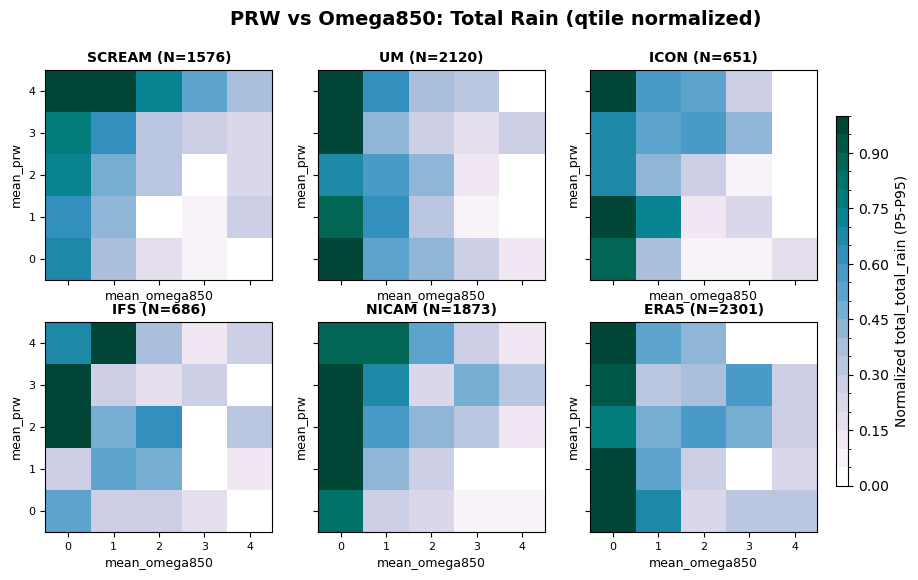

In [28]:
# Example 1: Plot all models with quantile normalization and extreme filtering
model_data = {'SCREAM': var_dfs_scream,   'UM': var_dfs_um, 'ICON': var_dfs_icon,   'IFS': var_dfs_ifs,
    'NICAM': var_dfs_nicam,    'ERA5': var_dfs_era5}

fig, axes, composites = plot_all_models_composite(
    model_data,var1='prw', var2='omega850',
    ren_var1='mean_prw', ren_var2='mean_omega850',
    varbins=5,value_feature='total_total_rain',
    filter_extremes=True,  # Remove p10-p90 extremes
    p_low=0.05, p_high=0.95,  # Extremes threshold
    min_count=15,  # Mask bins with < 10 samples
    normalize=True,  # Normalize data
    norm_method='quantile',  # Use quantile normalization (p10-p90)
    cmap=mycmap.whiteTOblueTOgreen,
    figsize=(12, 6),
    suptitle="PRW vs Omega850: Total Rain (qtile normalized)"
)

Removed 298 samples (10.0%) outside [4652.27, 52304.25] range
Removed 414 samples (10.0%) outside [5045.64, 70184.32] range
Removed 166 samples (10.1%) outside [3212.27, 64702.58] range
Removed 158 samples (10.1%) outside [5066.90, 104401.87] range
Removed 380 samples (10.0%) outside [5078.71, 76187.15] range
Removed 384 samples (10.0%) outside [7204.49, 123990.54] range


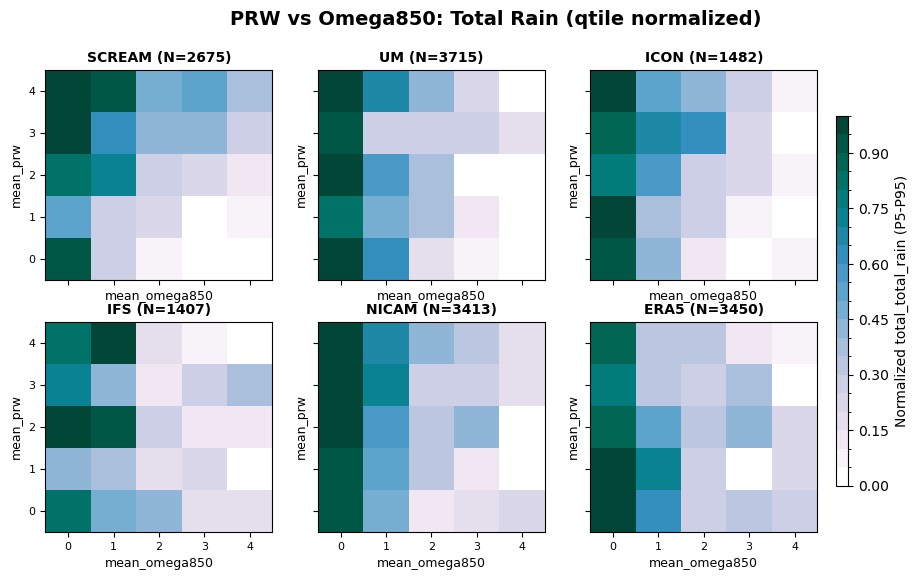

In [29]:
fig, axes, composites = plot_all_models_composite(
    model_data_nm,var1='prw', var2='omega850',
    ren_var1='mean_prw', ren_var2='mean_omega850',
    varbins=5,value_feature='total_total_rain',
    filter_extremes=True,  # Remove p10-p90 extremes
    p_low=0.05, p_high=0.95,  # Extremes threshold
    min_count=15,  # Mask bins with < 10 samples
    normalize=True,  # Normalize data
    norm_method='quantile',  # Use quantile normalization (p10-p90)
    cmap=mycmap.whiteTOblueTOgreen,
    figsize=(12, 6),
    suptitle="PRW vs Omega850: Total Rain (qtile normalized)"
)

Removed 176 samples (10.0%) outside [4432.30, 47084.79] range
Removed 236 samples (10.0%) outside [5112.86, 70787.28] range
Removed 74 samples (10.2%) outside [3323.40, 54579.57] range
Removed 78 samples (10.2%) outside [4643.91, 89065.25] range
Removed 208 samples (10.0%) outside [4563.53, 72873.03] range
Removed 256 samples (10.0%) outside [7218.32, 118650.42] range


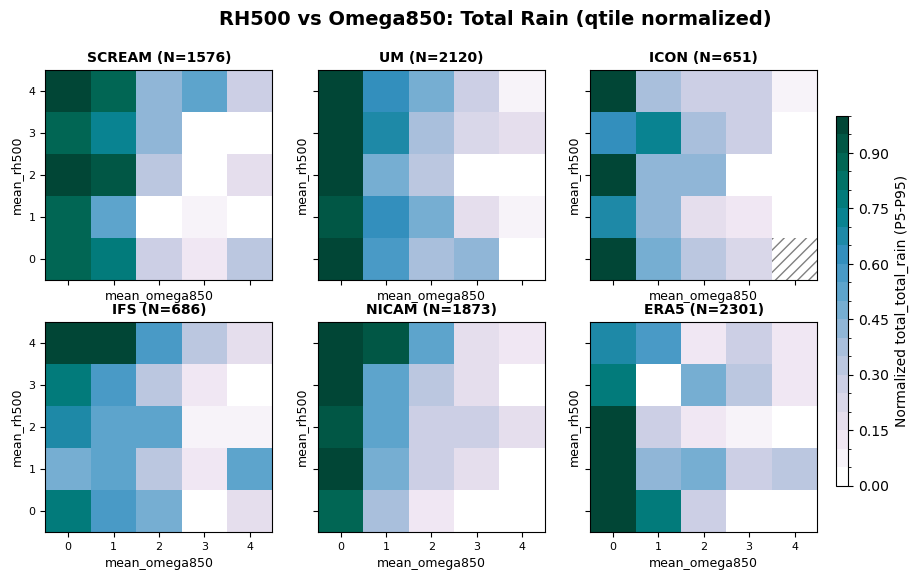

In [30]:
fig, axes, composites = plot_all_models_composite(
    model_data,var1='rh500', var2='omega850',
    ren_var1='mean_rh500', ren_var2='mean_omega850',
    varbins=5,value_feature='total_total_rain',
    filter_extremes=True,  # Remove p5-p95 extremes
    p_low=0.05, p_high=0.95,  # Extremes threshold
    min_count=15,  # Mask bins with < 10 samples
    normalize=True,  # Normalize data
    norm_method='quantile',  # Use quantile normalization (p10-p90)
    cmap=mycmap.whiteTOblueTOgreen,
    figsize=(12, 6),
    suptitle="RH500 vs Omega850: Total Rain (qtile normalized)"
)

Removed 298 samples (10.0%) outside [4652.27, 52304.25] range
Removed 414 samples (10.0%) outside [5045.64, 70184.32] range
Removed 166 samples (10.1%) outside [3212.27, 64702.58] range
Removed 158 samples (10.1%) outside [5066.90, 104401.87] range
Removed 380 samples (10.0%) outside [5078.71, 76187.15] range
Removed 384 samples (10.0%) outside [7204.49, 123990.54] range


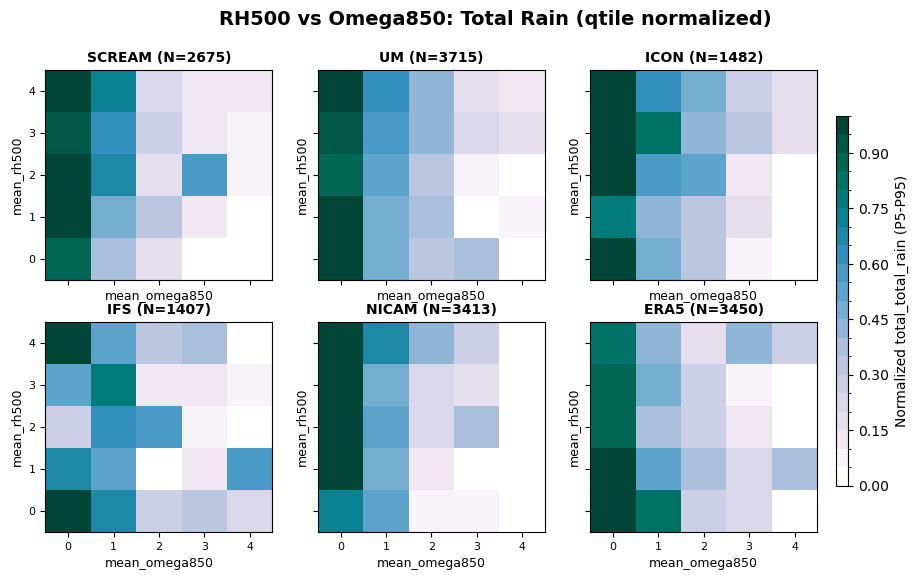

In [31]:
fig, axes, composites = plot_all_models_composite(
    model_data_nm,var1='rh500', var2='omega850',
    ren_var1='mean_rh500', ren_var2='mean_omega850',
    varbins=5,value_feature='total_total_rain',
    filter_extremes=True,  # Remove p5-p95 extremes
    p_low=0.05, p_high=0.95,  # Extremes threshold
    min_count=15,  # Mask bins with < 10 samples
    normalize=True,  # Normalize data
    norm_method='quantile',  # Use quantile normalization (p10-p90)
    cmap=mycmap.whiteTOblueTOgreen,
    figsize=(12, 6),
    suptitle="RH500 vs Omega850: Total Rain (qtile normalized)"
)

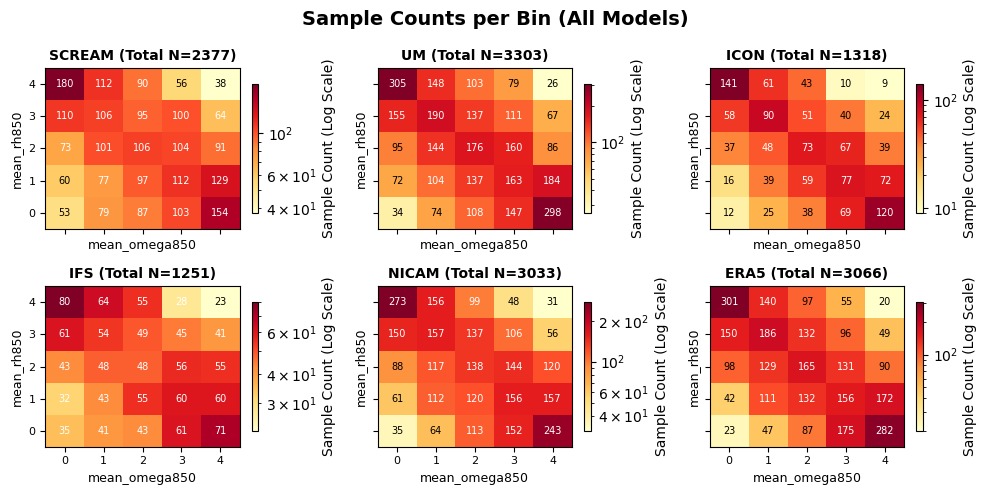

In [24]:
# Example 2: Plot sample counts for all models
fig_counts, axes_counts = plot_all_models_counts(
    composites,cmap='YlOrRd',figsize=(10, 5),
    suptitle="Sample Counts per Bin (All Models)"
) ##rh850 vs omega850 

Removed 176 samples (10.0%) outside [4432.30, 47084.79] range
Removed 236 samples (10.0%) outside [5112.86, 70787.28] range
Removed 74 samples (10.2%) outside [3323.40, 54579.57] range
Removed 78 samples (10.2%) outside [4643.91, 89065.25] range
Removed 208 samples (10.0%) outside [4563.53, 72873.03] range
Removed 256 samples (10.0%) outside [7218.32, 118650.42] range


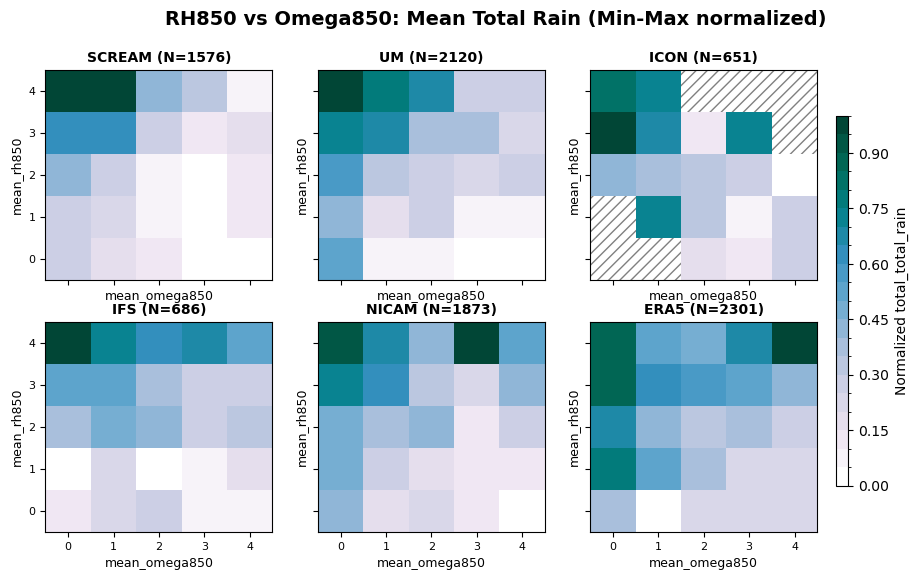

In [31]:
# Example 3: Min-max normalization instead of quantile
fig2, axes2, composites2 = plot_all_models_composite(
    model_data,
    var1='rh850', var2='omega850',
    varbins=5,
    value_feature='total_total_rain',
    filter_extremes=True,
    min_count=10, p_low=0.05, p_high=0.95, 
    normalize=True, 
    norm_method='minmax',  # Use min-max normalization
    cmap=mycmap.whiteTOblueTOgreen,
    figsize=(12, 6),
    suptitle="RH850 vs Omega850: Mean Total Rain (Min-Max normalized)"
)

Removed 176 samples (10.0%) outside [4432.30, 47084.79] range
Removed 236 samples (10.0%) outside [5112.86, 70787.28] range
Removed 74 samples (10.2%) outside [3323.40, 54579.57] range
Removed 78 samples (10.2%) outside [4643.91, 89065.25] range
Removed 208 samples (10.0%) outside [4563.53, 72873.03] range
Removed 256 samples (10.0%) outside [7218.32, 118650.42] range


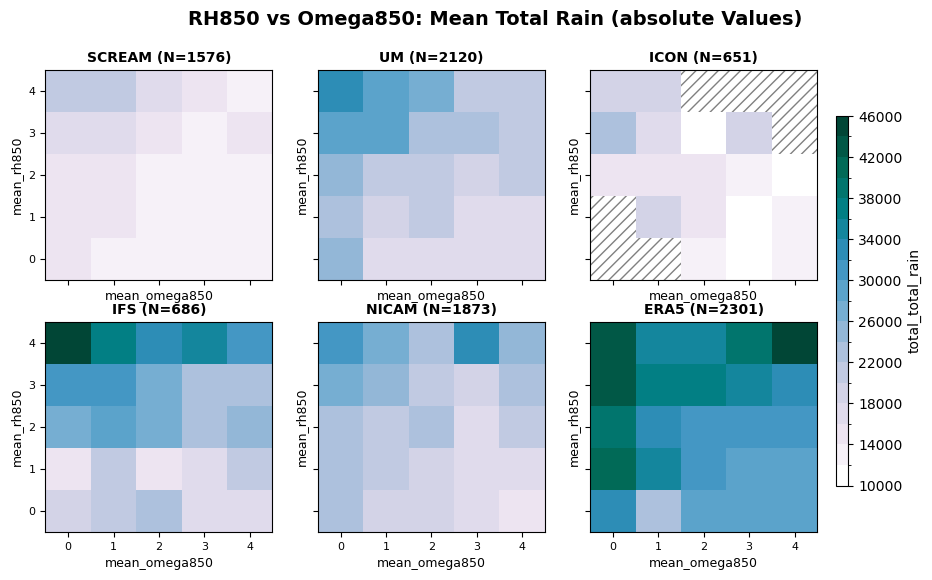

In [32]:
# Example 4: Without normalization (absolute values)
fig3, axes3, composites3 = plot_all_models_composite(
    model_data,var1='rh850', var2='omega850',
    varbins=5,value_feature='total_total_rain',
    filter_extremes=True,
    min_count=10,p_low=0.05, p_high=0.95, 
    normalize=False,  # No normalization - show absolute values
    cmap=mycmap.whiteTOblueTOgreen,
    figsize=(12, 6),
    suptitle="RH850 vs Omega850: Mean Total Rain (absolute Values)"
)

### Summary of Improvements

#### ✅ 1. Precipitation Extremes Filtering
- **Function**: `remove_precipitation_extremes()`
- Removes p10 and p90 precipitation extremes **before binning**
- Prevents extreme values from skewing bin means
- Customizable thresholds via `p_low` and `p_high` parameters

#### ✅ 2. Unified Multi-Model Plotting
- **Function**: `plot_all_models_composite()`
- Shows all models in a single figure for easy comparison
- Consistent colorbar scale across all models
- Bins with < 10 samples are masked (red hatching)
- No separate count subplots (cleaner visualization)

#### ✅ 3. Flexible Normalization Options
Two normalization methods available:
- **Quantile normalization** (`norm_method='quantile'`): Uses p10-p90 range (recommended)
- **Min-Max normalization** (`norm_method='minmax'`): Uses absolute min/max
- Can be disabled with `normalize=False` to show absolute values

#### ✅ 4. Separate Count Visualization
- **Function**: `plot_all_models_counts()`
- Shows sample counts in a separate figure
- Includes text labels showing exact counts per bin
- Uses log scale for better visibility

#### 🎯 Key Parameters:
- `filter_extremes=True`: Enable/disable extreme filtering
- `p_low=0.1, p_high=0.9`: Percentile thresholds for extremes
- `min_count=10`: Minimum samples required per bin (default: 10)
- `normalize=True/False`: Enable/disable normalization
- `norm_method='quantile'/'minmax'`: Choose normalization method

In [18]:
def plot_bivariate(composite,value_feature, feature_1,feature_2,
                   figs =(8,6),cmap = mycmap.whiteTOblueTOgreen, vmin=None,vmax=None,nbins=20, normalize=True,qtile_norm=True):
    
    fig, ax = plt.subplots(figsize=figs)
    cmap = plt.get_cmap(cmap); 
    
    data = composite.values
    if normalize:
        if qtile_norm:
            data = (data - np.nanquantile(data,0.1)) / (np.nanquantile(data,0.9) - np.nanquantile(data,0.1))
        else:
            data = (data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data))
        
        vmin, vmax = 0, 1  # overwrite   
    else:
        if vmin is None: vmin = np.nanmin(data)
        if vmax is None: vmax = np.nanmax(data)
  
    levels = MaxNLocator(nbins=nbins).tick_values(vmin, vmax) 
    # Create BoundaryNorm
    norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
    
    # Use pcolormesh for accurate grid plotting
    mesh = ax.pcolormesh(data, cmap=cmap, norm=norm)
    fig.colorbar(mesh, ax=ax, label=f"Mean {value_feature}", extend='neither')
    
    # Set ticks and labels using the bin categories from the unstacked dataframe
    ax.set_xticks(np.arange(composite.shape[1]) + 0.5)
    ax.set_xticklabels([str(c) for c in composite.columns], rotation=45, ha='right')
    ax.set_xlabel(f"Binned {feature_2}")
    
    ax.set_yticks(np.arange(composite.shape[0]) + 0.5)
    ax.set_yticklabels([str(c) for c in composite.index])
    ax.set_ylabel(f"Binned {feature_1}")
    plt.tight_layout()
    return(data)
    

In [19]:
def plot_mean_and_count_composites(composite_mean, composite_count, info,
                                     fig_title="Composite Analysis", cmap_mean='viridis', cmap_count='plasma',nbins=20,normalize=True,qtile_norm=False):
    """
    Plots the mean composite and the sample count composite side-by-side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
    fig.suptitle(fig_title, fontsize=11)

    # --- Plot 1: Mean Composite ---
    ax1 = axes[0]
    data_mean = composite_mean.values

    if normalize:
        if qtile_norm:
            data_mean = (data_mean - np.nanquantile(data_mean,0.1)) / (np.nanquantile(data_mean,0.9) - np.nanquantile(data_mean,0.1))
        else:
            data_mean = (data_mean - np.nanmin(data_mean)) / (np.nanmax(data_mean) - np.nanmin(data_mean))
        
        vmin, vmax = 0, 1  # overwrite   
    else:
        if vmin is None: vmin = np.nanmin(data)
        if vmax is None: vmax = np.nanmax(data)
            
    levels = MaxNLocator(nbins=nbins).tick_values(vmin, vmax) 
    # Create BoundaryNorm
    norm = BoundaryNorm(levels, ncolors=cmap_mean.N, clip=True)
    mesh1 = ax1.pcolormesh(data_mean, cmap=cmap_mean, norm=norm)
    
    fig.colorbar(mesh1, ax=ax1, label=f"Mean {info['value_feature']}")
    ax1.set_title(f"Mean of {info['value_feature']}")

    # --- Plot 2: Count Composite ---
    ax2 = axes[1]
    data_count = composite_count.fillna(0).values # Fill NaN with 0 for counts
    mesh2 = ax2.pcolormesh(data_count, cmap=cmap_count, norm=plt.cm.colors.LogNorm()) # Use LogNorm for better color scale
    fig.colorbar(mesh2, ax=ax2, label="Sample Count (Log Scale)")
    ax2.set_title("Sample Count per Bin")
    
    # Add text for counts on the count plot for clarity
    for i in range(composite_count.shape[0]):
        for j in range(composite_count.shape[1]):
            ax2.text(j + 0.5, i + 0.5, f'{int(data_count[i, j])}',
                     ha='center', va='center', color='white', fontsize=8)

    # --- Set labels for both plots ---
    for ax in axes:
        ax.set_xticks(np.arange(composite_mean.shape[1]) + 0.5)
        # ax.set_xticklabels([str(c) for c in info['bin_edges_2']], rotation=45, ha='right')
        ax.set_xlabel(f"Binned {info['feature_2']}")
        
    axes[0].set_yticks(np.arange(composite_mean.shape[0]) + 0.5)
    # axes[0].set_yticklabels([str(c) for c in info['bin_edges_1']])
    axes[0].set_ylabel(f"Binned {info['feature_1']}")
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Example Usage ---
# composite_mean, composite_count, plot_info = create_composite_grid(df1, df2, varbins=5)
# plot_mean_and_count_composites(composite_mean, composite_count, plot_info)

In [20]:
def plot_hexbin_mean_and_count(df_1, df_2, var1='mean', ren_var1='mean_rh850',
                               var2='mean', ren_var2='mean_omega850',
                               key_cols=['track_id'],
                               value_feature='mean_rain', gridsize=15, mincnt=1,
                               cmap='viridis'):
    """
    Creates a side-by-side hexbin plot showing both the mean of a third variable
    and the count of samples in each bin.
    """
    # Prepare dataframes by renaming and merging
    df_1 = df_1.rename(columns={var1: ren_var1})
    df_2 = df_2.rename(columns={var2: ren_var2})
    merge_cols_df1 = key_cols + [ren_var1, value_feature]
    df_merged = df_1[merge_cols_df1].merge(df_2[key_cols + [ren_var2]], on=key_cols, how='inner')
    df_merged.dropna(subset=[ren_var1, ren_var2, value_feature], inplace=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
    fig.suptitle(f"Hexbin Analysis (Gridsize: {gridsize}, Min Count: {mincnt})", fontsize=10)

    # --- Plot 1: Mean of the Value Feature ---
    ax1 = axes[0]
    hb_mean = ax1.hexbin(
        y=df_merged[ren_var1],
        x=df_merged[ren_var2],
        C=df_merged[value_feature],
        gridsize=gridsize,
        reduce_C_function=np.mean,
        mincnt=mincnt, # Apply the minimum count threshold
        cmap=cmap
    )
    fig.colorbar(hb_mean, ax=ax1, label=f"Mean {value_feature}")
    ax1.set_title(f"Mean of {value_feature}")

    # --- Plot 2: Log of the Sample Count ---
    ax2 = axes[1]
    hb_count = ax2.hexbin(
        y=df_merged[ren_var1],
        x=df_merged[ren_var2],
        gridsize=gridsize,
        mincnt=mincnt, # Apply the same threshold for consistency
        cmap=cmap,
        bins='log' # Use a logarithmic scale for counts
    )
    fig.colorbar(hb_count, ax=ax2, label="Sample Count (Log Scale)")
    ax2.set_title("Sample Count per Hexagon")

    # Set labels for both plots
    for ax in axes:
        ax.set_xlabel(ren_var1)
    axes[0].set_ylabel(ren_var2)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Example Usage ---
# plot_hexbin_mean_and_count(df1, df2, gridsize=20, mincnt=5)

### SCREAM model

In [89]:
composite_scream_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(var_dfs_scream['rh850'],
                                                var_dfs_scream['omega850'],
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',varbins=5,value_feature='mean_total_rain')

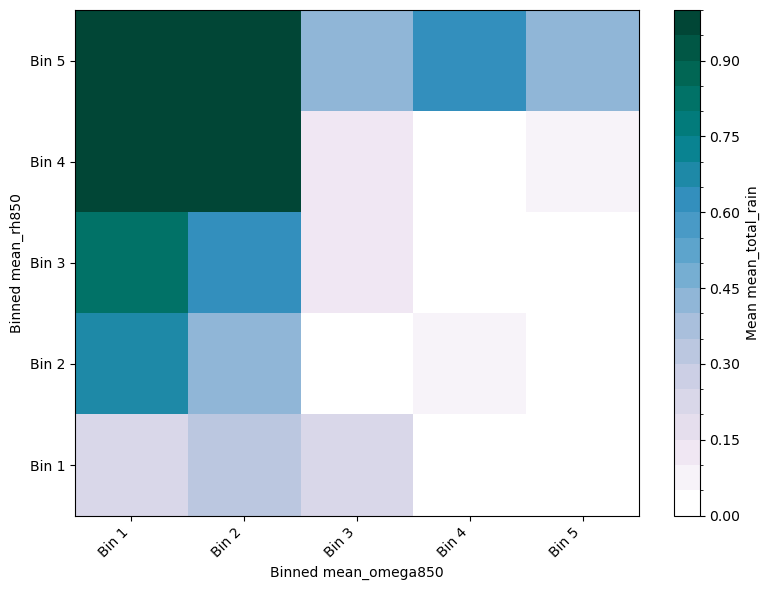

In [91]:
d1 = plot_bivariate(composite_scream_rh850_w850,value_feature,ft_1,ft_2,normalize=True,qtile_norm=True)

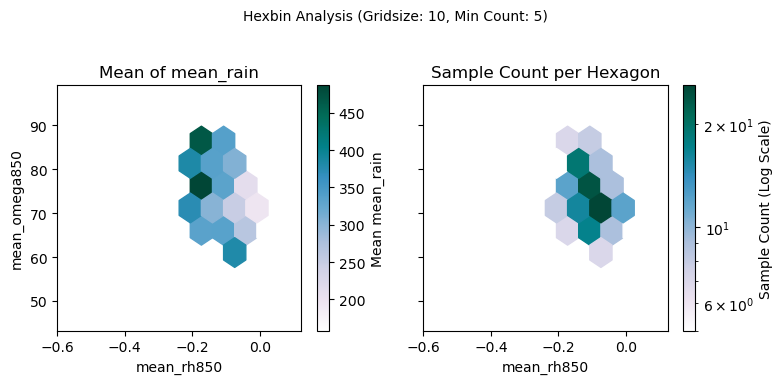

In [186]:
plot_hexbin_mean_and_count(filtered_df_rh850_scream_r2, filtered_scream_omega850[(filtered_scream_omega850.radius==radius)&(filtered_scream_omega850.time_offset_hours==0)].copy(), gridsize=10,cmap=mycmap.whiteTOblueTOgreen,mincnt=5)

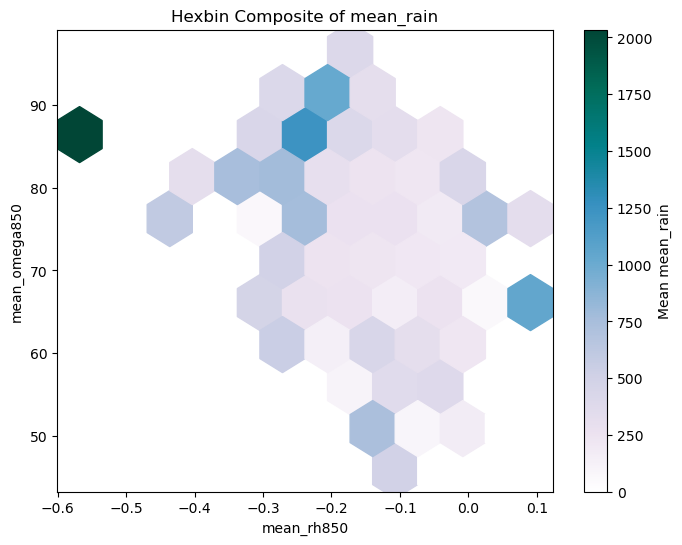

In [155]:
plot_hexbin_composite(filtered_df_rh850_scream_r2, filtered_scream_omega850[(filtered_scream_omega850.radius==radius)&(filtered_scream_omega850.time_offset_hours==0)].copy(), gridsize=10,cmap=mycmap.whiteTOblueTOgreen)

In [129]:
composite_count.sum().sum()

np.int64(259)

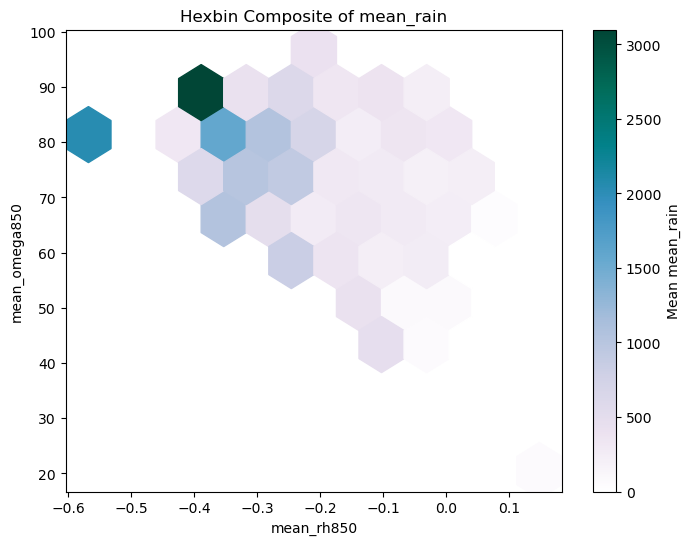

In [159]:
plot_hexbin_composite(filtered_df_rh850_scream_r2, filtered_scream_omega850_v2[(filtered_scream_omega850_v2.radius==radius)&(filtered_scream_omega850_v2.time_offset_hours==0)].copy(), gridsize=10,cmap=mycmap.whiteTOblueTOgreen)

In [204]:
def get_key_stages_with_tmax(df):
    results = []

    for track_id, g in df.groupby("track"):
        g = g.sort_values("time_offset_hours")

        # 1) Mature state: nearest to time_to_max_totrain
        tmax = g["time_to_max_totrain"].iloc[0]  # same for all rows in track
        mature_idx = (g["time_offset_hours"] - tmax).abs().idxmin()
        mature_row = g.loc[mature_idx]
        mature_time = mature_row["time_offset_hours"]

        # 2) Midpoint between 0 and mature
        if (g["time_offset_hours"] >= 0).any():
            start_time = g[g["time_offset_hours"] >= 0]["time_offset_hours"].min()
        else:
            continue
        mid1_time = (start_time + mature_time) / 2
        mid1_row = g.iloc[(g["time_offset_hours"] - mid1_time).abs().argmin()]

        # 3) Midpoint between mature and termination
        end_time = g["time_offset_hours"].max()
        mid2_time = (mature_time + end_time) / 2
        mid2_row = g.iloc[(g["time_offset_hours"] - mid2_time).abs().argmin()]

        results.extend([
            {**mature_row.to_dict(), "stage": "mature"},
            {**mid1_row.to_dict(), "stage": "growing"},
            {**mid2_row.to_dict(), "stage": "decaying"},
        ])

    return pd.DataFrame(results)

In [81]:
df_rh850_sel_era5 = get_key_stages_with_tmax(filtered_df_rh850_era5[(filtered_df_rh850_era5.radius==3.5)])
df_om850_sel_era5 = get_key_stages_with_tmax(filtered_df_w850_era5[(filtered_df_w850_era5.radius==3.5)])

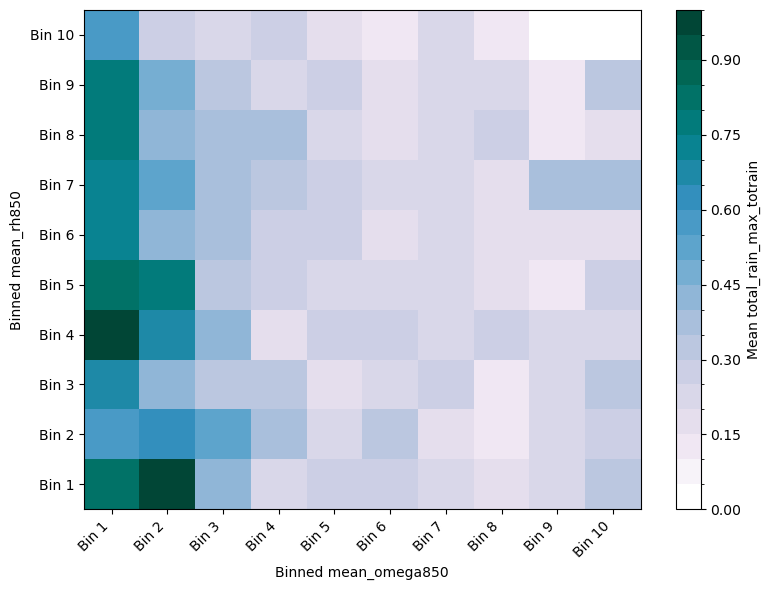

In [82]:
composite_era5_rh850_w850, value_feature, ft_1,ft_2 = get_composite_data(df_rh850_sel_era5[df_rh850_sel_era5.stage=='growing'].copy(), 
                                                                         df_om850_sel_era5[df_om850_sel_era5.stage=='growing'].copy(),
                                                var1= 'mean',ren_var1 = 'mean_rh850',var2= 'mean', ren_var2 = 'mean_omega850',key_cols=['track'],
                                                                         value_feature='total_rain_max_totrain')
plot_bivariate(composite_era5_rh850_w850,value_feature,ft_1,ft_2)